# Data Visualization

In [6]:
# Load data set
import pandas as pd
import altair as alt

new_data = pd.read_csv("../data/new_data.csv")
expend = pd.read_csv("../data/expenditures.csv")
farm_income = pd.read_csv("../data/farm_income.csv")

In [2]:
# Define Color Palette
colors = ['#4682B4', '#4F7942', '#FFD700', '#CC5500']

## Plot 1: Agricultural Expenses

In [3]:
# Subset Code by attribute
filtered = expend[expend['Attribute'].isin(['Public agricultural and food R&D (constant 2022 U.S. dollars- millions)', 'Private food industry R&D (constant 2022 U.S. dollars- millions)'])]
filtered = filtered[filtered['Year'] != 2022]

# Split attributes
filtered_public = filtered[filtered['Attribute'].isin(['Public agricultural and food R&D (constant 2022 U.S. dollars- millions)'])]
filtered_private = filtered[filtered['Attribute'].isin(['Private food industry R&D (constant 2022 U.S. dollars- millions)'])]

In [ ]:
area1 = alt.Chart(filtered_public).mark_area(color = '#4682B4', opacity=0.5).encode(
    x=alt.X('Year', axis=alt.Axis(format='.0f')),
    y=alt.Y('Value', title='U.S. Dollars (Millions)')
).properties(title='Total Research & Development Expenditure (Public Sector)')

line1 = alt.Chart(filtered_public).mark_line(color = '#4682B4').encode(
    x=alt.X('Year', axis=alt.Axis(format='.0f')),
    y=alt.Y('Value', title='U.S. Dollars (Millions)')
).properties(title='Total Research & Development Expenditure (Public Sector)')

area2 = alt.Chart(filtered_private).mark_area(color = '#4F7942', opacity=0.5).encode(
    x=alt.X('Year', axis=alt.Axis(format='.0f')),
    y=alt.Y('Value', title='U.S. Dollars (Millions)')
).properties(title='Total Research & Development Expenditure (Private Sector)')

line2 = alt.Chart(filtered_private).mark_line(color = '#4F7942').encode(
    x=alt.X('Year', axis=alt.Axis(format='.0f')),
    y=alt.Y('Value', title='U.S. Dollars (Millions)')
).properties(title='Total Research & Development Expenditure (Private Sector)')

chart1 = area1 + line1
chart2 = area2 + line2

combined = chart1 | chart2
combined
combined.save('../website/plots/plot1.svg')

## Plot 2: GE Corn

In [243]:
# Filter data set
filtered = new_data[new_data['Crop'] == "Corn"]
filtered = filtered[filtered['Attribute'] == "All GE varieties (percent of all corn planted) 3/"]
filtered = filtered[~filtered['State'].isin(['Other States', 'United States'])]

In [244]:
state_to_id = {
    "Illinois": 17,
    "Indiana": 18,
    "Iowa": 19,
    "Kansas": 20,
    "Michigan": 26,
    "Minnesota": 27,
    "Missouri": 29,
    "Nebraska": 31,
    "North Dakota": 38,
    "Ohio": 39,
    "South Dakota": 46,
    "Texas": 48,
    "Wisconsin": 55
}
filtered['state_id'] = filtered['State'].map(state_to_id)
filtered['state_id'] = filtered['state_id'].apply(lambda x: int(x))

In [245]:
filtered = filtered.dropna(subset=['Value'])
filtered = filtered[['state_id', 'Value', 'Year']]

In [246]:
from vega_datasets import data

# Load States
states = alt.topo_feature(data.us_10m.url, 'states')

In [251]:
year_slider = alt.param(
    value=2000,
    bind=alt.binding_range(min=2000, max=2025, step=1, name="Year: ")
)

base = alt.Chart(filtered).mark_geoshape().encode(
    color=alt.Color('Value:Q', scale=alt.Scale(domain = [0,75,100], range=['#FFD700', '#4F7942', '#4682B4']), title = 'Percent')
).transform_filter(
    alt.datum.Year == year_slider
).transform_lookup(
    lookup='state_id',
    from_=alt.LookupData(states, 'id', ['type', 'properties', 'geometry'])
).project('albersUsa').add_params(year_slider)

borders = alt.Chart(states).mark_geoshape(
    fill=None,
    stroke='black',
    strokeWidth=1
).project('albersUsa')

chart = (base + borders).properties(
    title=alt.TitleParams(text='All Genetically Engineered Varieties Of Corn By State (2000-2025)', fontSize=16),
    width = 600,
    height = 400)

chart.save('../website/plots/plot2.html')

# Plot 3: By Crop

In [232]:
# Filter data set
filtered = new_data[new_data['State'] == "United States"]
filtered = filtered[filtered['Attribute'].isin(['All GE varieties (percent of all corn planted) 3/', 'All GE varieties (percent of all upland cotton planted) 3/', 'All GE varieties (percent of all soybeans planted)'])]

In [238]:
# Set color range
color_range = [ '#FFD700', '#CC5500', '#4F7942']

In [241]:
# Create selection criteria
select_crop = alt.selection_point(
    fields=["Crop"],
    bind=alt.binding_select(options=list(filtered["Crop"].unique()),name="Select Crop "),
    value="Corn")

# Create chart
chart = (
    alt.Chart(filtered)
    .mark_bar()
    .encode(
        x=alt.X("Year:N", title = "Year", axis=alt.Axis(labelFontSize = 12, titleFontSize=14)),
        y=alt.Y("Value:Q", scale=alt.Scale(domain = [0,100]), title = "Percent of all Planted (%)", axis=alt.Axis(labelFontSize = 12, titleFontSize=14)),
        color=alt.Color("Crop:N", scale=alt.Scale(domain = ['Corn', 'Cotton', 'Soybeans'], range = color_range), 
                        title = "Crop", legend = alt.Legend(labelFontSize=12, titleFontSize=12)),
        tooltip=[alt.Tooltip('Value', title = "Percent of all Planted (%)")]
    )
    .add_params(select_crop)
    .transform_filter(select_crop)
    .properties(title = alt.TitleParams(text = 'All Genetically Engineered Varieties By Year And Crop (2000-2025)', fontSize=16), width = 500)
)

chart.save('../website/plots/plot3.html')

# Plot 4: By State

In [280]:
# Filter data set
filtered = new_data[new_data['State'] != "United States"]

# Look just at Herbicide-intolerant
filtered = filtered[filtered['Attribute'].isin(['Herbicide-tolerant (HT) only (percent of all corn planted)', 'Herbicide-tolerant (HT) only (percent of all upland cotton planted)', 'Herbicide-tolerant (HT) only (percent of all soybeans planted)'])]
filtered_year = filtered[filtered['Year'] == 2025]

# Reset Index
filtered = filtered.reset_index(drop=True)
filtered_year = filtered_year.reset_index(drop=True)

# Crop
filtered_cotton = filtered[filtered['Crop'] == 'Cotton']
filtered_corn = filtered[filtered['Crop'] == 'Corn']
filtered_soybeans = filtered[filtered['Crop'] == 'Soybeans']

In [281]:
all_values = ['Alabama', 'Arkansas', 'California', 'Corn', 'Cotton', 'Georgia', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Louisiana', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Nebraska', 'North Carolina', 'North Dakota', 'Ohio', 'Other States', 'South Dakota', 'Soybeans', 'Tennessee', 'Texas', 'Wisconsin']
all_colors = ['#111184', '#023020', '#FF8C00', '#4F7942', '#CC5500', '#8B8000', '#0000CD', '#3CB371', '#F08000', '#FFD700', '#87CEFA', '#088F8F', '#F88379', '#FFC000', '#00CED1', '#008080', '#FF7F50', '#F89880', '#FFCE1B', '#000080', '#0047AB', '#4682B4', '#808000', '#228B22', '#FFA800']
color_scale = alt.Scale(domain=all_values, range=all_colors)

In [282]:
selection = alt.selection_point(name='bar_select', fields=['State', 'Crop'])

bar_chart = alt.Chart(filtered_year).mark_bar().encode(
    x=alt.X('State:N', title='State', axis=alt.Axis(labelFontSize=12, titleFontSize=14)),
    y=alt.Y('Value:Q', title='Percent Of All Planted (%)', axis=alt.Axis(labelFontSize=12, titleFontSize=14)),
    color=alt.Color('Crop:N', scale=color_scale, legend=None),
    xOffset='Crop:N',
    opacity=alt.condition(selection, alt.value(1.0), alt.value(0.2))
).properties(
    title=alt.TitleParams(
        text='Total Herbicide-tolerant (Ht) Only Genetically Engineered Crops (2025)',
        fontSize=16),
        width=660,
        height=300
    
).add_params(selection)

line_chart1 = alt.Chart(filtered_corn).mark_line().encode(
    x=alt.X('Year:N', title='Year', axis=alt.Axis(labelFontSize=8)),
    y=alt.Y('Value:Q', title='Percent Of All Planted (%)', axis=alt.Axis(labelFontSize=12, titleFontSize=12)),
    color=alt.Color('State:N', scale=color_scale, legend=None),
    opacity=alt.condition(selection, alt.value(1.0), alt.value(0.1))
).properties(
    title=alt.TitleParams(
        text='Herbicide-tolerant Corn (2000-2025)',
        fontSize=11),
        width=200,
        height=200
    )

line_chart2 = alt.Chart(filtered_cotton).mark_line().encode(
    x=alt.X('Year:N', title='Year', axis=alt.Axis(labelFontSize=8)),
    y=alt.Y('Value:Q', title=""),
    color=alt.Color('State:N', scale=color_scale, legend=None),
    opacity=alt.condition(selection, alt.value(1.0), alt.value(0.1))
).properties(
    title=alt.TitleParams(
        text='Herbicide-tolerant Cotton (2000-2025)',
        fontSize=11),
        width=200,
        height=200
    )

line_chart3 = alt.Chart(filtered_soybeans).mark_line().encode(
    x=alt.X('Year:N', title='Year', axis=alt.Axis(labelFontSize=8)),
    y=alt.Y('Value:Q', title = ""),
    color=alt.Color('State:N', scale=color_scale, legend=None),
    opacity=alt.condition(selection, alt.value(1.0), alt.value(0.1))
).properties(
    title=alt.TitleParams(
        text='Herbicide-tolerant Soybeans (2000-2025)',
        fontSize=11),
        width=200,
        height=200
    )

linked_chart = bar_chart & (line_chart1 | line_chart2 | line_chart3)
linked_chart.save('../website/plots/plot4.html')

# Plot 5: By Income

In [283]:
import plotly.express as px

fig = px.treemap(
    farm_income.assign(GE=farm_income["GE"].astype(str)),
    path=["State"],       
    values="Share_income",            
    color="GE", 
    color_discrete_map={
        "1" : '#4F7942',
        "0" : '#CC5500',
    }       
)

fig.update_traces(texttemplate="%{label}<br>%{value:.1f}%")
fig.update_layout(title = dict(text="Percent of all U.S. Farm Income by State (2024)", x=0.5, font=dict(family="Helvetica")), margin=dict(t=40, l=0, r=0, b=0))

fig.show()

In [284]:
fig.write_image("../website/plots/plot5.svg")

# Plot 6: Infographic

In [228]:
# KPI cards

kpi_data1 = pd.DataFrame([{'label': '-> Processed Foods in Grocery Stores with GE Ingredients: 70%'}])
kpi_data2 = pd.DataFrame([{'label': '-> U.S. Adults who think GE Foods are Unhealthy: 51%'}])

kpi1 = alt.Chart(kpi_data1).mark_text(fontSize=12, fontWeight='bold').encode(
    text='label:N').properties(width=300, height=50)

kpi2 = alt.Chart(kpi_data2).mark_text(fontSize=12, fontWeight='bold').encode(
    text='label:N').properties(width=300, height=50)

In [255]:
# Data set up
pie_data = farm_income.groupby("GE")["Share_income"].sum().reset_index()
pie_data["GE"] = pie_data["GE"].replace(0, "Not Large GE Contributor")
pie_data["GE"] = pie_data["GE"].replace(1, "Large GE Contributor")

In [257]:
# Pie Chart
chart = alt.Chart(pie_data).mark_arc(innerRadius=50).encode(
    theta=alt.Theta('Share_income:Q', stack = True),
    color=alt.Color('GE:N', scale=alt.Scale(
        domain=pie_data['GE'].tolist(),
        range=['#4682B4', '#CC5500']),
        legend=None)
).properties(width=200, height=200, title = "Farm Income Based on GE State Crop Contribution (%)")

labels = alt.Chart(pie_data).mark_text(radius=130, fontSize=11).encode(
    theta=alt.Theta('Share_income:Q', stack=True),
    text='GE:N',
    color=alt.Color('GE:N', legend=None,
        scale=alt.Scale(
            domain=["Large GE Contributor", "Not Large GE Contributor"],
            range=['#CC5500', '#4682B4']
        ))
)

pie = (chart + labels).properties(width=150, height=200)

pie

alt.LayerChart(...)

In [260]:
# Filter data set
filtered = new_data[new_data['State'] == "United States"]
filtered = filtered[filtered['Attribute'].isin(['All GE varieties (percent of all corn planted) 3/', 'All GE varieties (percent of all upland cotton planted) 3/', 'All GE varieties (percent of all soybeans planted)'])]

# Grab the average
bar_data = filtered.groupby("Year")[["Value"]].mean().reset_index()

In [189]:
# Bar Chart
bar = alt.Chart(bar_data).mark_bar(color='#4F7942').encode(
    x=alt.X('Year:N'),
    y=alt.Y('Value:Q', title = 'Percent Of All Planted (%)')
).properties(width=300, height=200, title = "Average Genetically Engineered Crops in the U.S.")

bar

alt.Chart(...)

In [ ]:
# Filter data set
filtered = new_data[new_data['State'] == "United States"]
filtered = filtered[filtered['Attribute'].isin(['All GE varieties (percent of all corn planted) 3/', 'All GE varieties (percent of all upland cotton planted) 3/', 'All GE varieties (percent of all soybeans planted)'])]

In [186]:
# Line chart

line_chart = alt.Chart(filtered).mark_line().encode(
    x=alt.X('Year', axis=alt.Axis(format='.0f')),
    y=alt.Y('Value:Q', title='Percent Of All Planted (%)'),
    color=alt.Color('Crop:N', scale=alt.Scale(
        domain=filtered['Crop'].tolist(),
        range=['#FFD700', '#CC5500', '#4F7942']))
).properties(width = 600, height = 150, title='Growth in Genetically Engineered Crops (2000-2025)')

line_chart

alt.Chart(...)

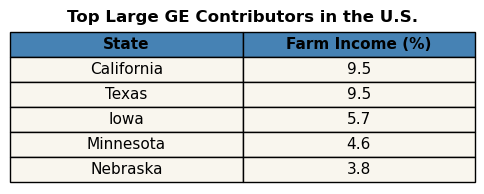

In [267]:
table_data = [['California',9.5],
              ['Texas', 9.5],
              ['Iowa', 5.7],
              ['Minnesota', 4.6],
              ['Nebraska', 3.8]]

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 2))
ax.axis('off')

table = ax.table(
    cellText=table_data,
    colLabels=['State', 'Farm Income (%)'],
    cellLoc='center',
    loc='center'
)
ax.set_title("Top Large GE Contributors in the U.S.", fontweight='bold')

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.5)

for col in range(2):
    table[0, col].set_facecolor('#4682B4')
    table[0, col].set_text_props(color='black', fontweight='bold')

for row in range(1,6):
    table[row, 0].set_facecolor('#F9F6EE')
    table[row, 1].set_facecolor('#F9F6EE')

plt.savefig('../tables/table1.png', dpi=150, bbox_inches='tight', transparent=True)

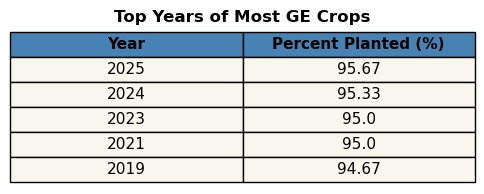

In [268]:
table_data = [['2025',95.67],
              ['2024', 95.33],
              ['2023', 95.00],
              ['2021', 95.00],
              ['2019', 94.67]]

fig, ax = plt.subplots(figsize=(6, 2))
ax.axis('off')

table = ax.table(
    cellText=table_data,
    colLabels=['Year', 'Percent Planted (%)'],
    cellLoc='center',
    loc='center'
)
ax.set_title("Top Years of Most GE Crops", fontweight='bold')

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.5)

for col in range(2):
    table[0, col].set_facecolor('#4682B4')
    table[0, col].set_text_props(color='black', fontweight='bold')

for row in range(1,6):
    table[row, 0].set_facecolor('#F9F6EE')
    table[row, 1].set_facecolor('#F9F6EE')

plt.savefig('../tables/table2.png', dpi=150, bbox_inches='tight', transparent=True)

In [269]:
import base64

# Convert table PNG to base64
with open('../tables/table1.png', 'rb') as f:
    b64 = base64.b64encode(f.read()).decode()

url = f"data:image/png;base64,{b64}"

# Wrap it as an Altair chart
table_chart1 = alt.Chart(
    pd.DataFrame([{'url': url}])
).mark_image(
    width=300,
    height=150
).encode(
    url='url:N'
).properties(width=100, height=80)

In [270]:
# Convert table PNG to base64
with open('../tables/table2.png', 'rb') as f:
    b64 = base64.b64encode(f.read()).decode()

url = f"data:image/png;base64,{b64}"

# Wrap it as an Altair chart
table_chart2 = alt.Chart(
    pd.DataFrame([{'url': url}])
).mark_image(
    width=300,
    height=150
).encode(
    url='url:N'
).properties(width=100, height=80)

alt.VConcatChart(...)
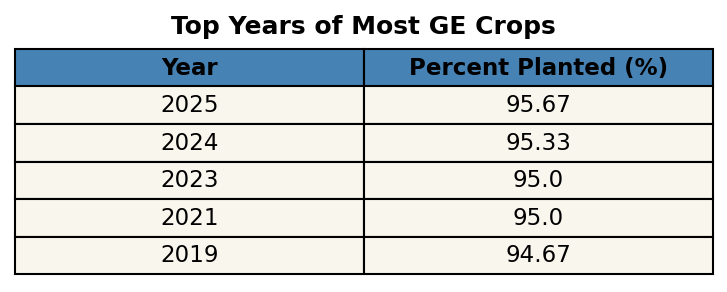
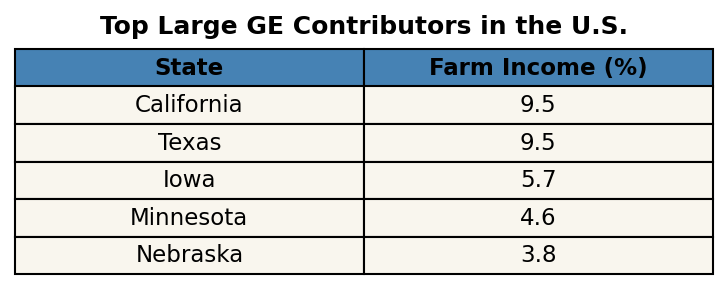

In [271]:
infographic = alt.vconcat(
    alt.hconcat(kpi1, kpi2),
    alt.hconcat(bar, pie),
    alt.hconcat(table_chart2, table_chart1).resolve_scale(color='independent'),
    alt.hconcat(line_chart).resolve_scale(color='independent'),
    center=True
).properties(
    title=alt.TitleParams('Overview of Genetically Engineered Crops in the U.S.',
    anchor = 'middle',
    fontSize=24)
).configure(
    background='#F9F6EE'
).configure_view(
    strokeWidth=0 
)

infographic

In [272]:
infographic.save('../website/plots/plot6.html')